### PyTorch workflow

#### Resource

- notebook: https://www.learnpytorch.io/01_pytorch_workflow/


### What we will cover:

- data (prepare and load)
- build model
- fitting the model to data (training)
- making predictions and evaluating a model (inference)
- saving and loading the model

In [ ]:
import torch
from torch import nn # nn conatains all of Pytorch's building blocks for neural networks
import matplotlib.pyplot as plt

# check PyTorch version
torch.__version__

'2.10.0+cpu'

### Data (preparing and loading)

Data can be almost anything in ML

- Excel spreadsheet
- Images of any kind
- Videos, Audios
- Text
- DNA
- etc

ML contains 2 parts:

1. Turn data into numerical representation.
2. Build a model (or use a pre-trained model) to learn patterns in that numerical representation.

### PyToech model buidling essentials

* torch.nn - contains all the buildings for computational graph (a neural network can be considered a computational graph)

* torch.nn.parameters - what paramenters should our model try and learn, often a PyTorch layer from torch.nn will set these for us

* torch.nn.module - The base class for all neural network modules, if we subclass it, we should overwrite forward()

* torch.optim - This is where the optimizers in PyTorch live, they helps with gradient descent

* def forward() - all nn.module subclasses require us to overwrite forward(), this method defines what happens in the forward computation

In [ ]:
# --- 1. Create Data ---
weight = 0.7
bias = 0.3

X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)  # shape: [50, 1]
y = weight * X + bias                            # y = 0.7x + 0.3

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# --- 2. Train/Test Split (80/20) ---
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


In [ ]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})
    # Show the plot
    plt.show()


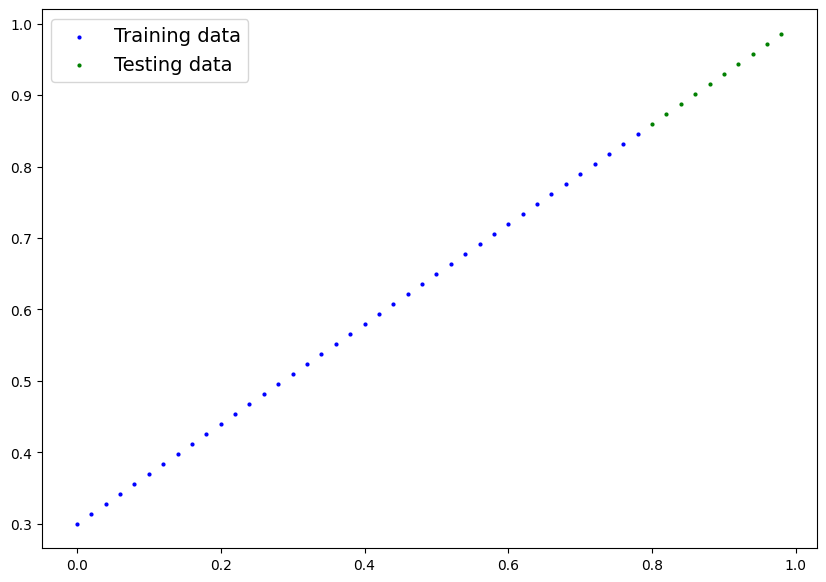

In [ ]:
plot_predictions(X_train,y_train, X_test, y_test)

In [ ]:
# --- 3. Define Model ---
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # self.weights = nn.Parameter(torch.randn(1))
        # self.bias = nn.Parameter(torch.randn(1))

        # Instead of initializing the parameters by ourselves, we can initialize
        # the layers that have the parameters inbuilt them selves (using pre-existing layers)
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    # we can also add "Python's type-int":
    # def forward(self, x: torch.Tensor) -> torch.Tensor:
    def forward(self, x):
        # return self.weights * x + self.bias
        return self.linear_layer(x)


### Building the training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:

0. Loop through the data
1. Forward pass (this involves data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation  
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calcualte the gradient of each parameters of our model WRT the loss (**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)


In [ ]:
torch.manual_seed(42)
model = LinearRegressionModel()
model, model.state_dict()
# --- 4. Loss & Optimizer ---
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Make a prediction with the untrained model
model.eval()
with torch.inference_mode():
    initial_preds = model(X_test)


Epoch 0 | Train Loss: 0.0007 | Test Loss: 0.0022
OrderedDict({'linear_layer.weight': tensor([[0.5934]]), 'linear_layer.bias': tensor([0.3486])})
Epoch 20 | Train Loss: 0.0006 | Test Loss: 0.0023
OrderedDict({'linear_layer.weight': tensor([[0.5947]]), 'linear_layer.bias': tensor([0.3462])})
Epoch 40 | Train Loss: 0.0006 | Test Loss: 0.0023
OrderedDict({'linear_layer.weight': tensor([[0.5963]]), 'linear_layer.bias': tensor([0.3444])})
Epoch 60 | Train Loss: 0.0006 | Test Loss: 0.0023
OrderedDict({'linear_layer.weight': tensor([[0.5979]]), 'linear_layer.bias': tensor([0.3430])})
Epoch 80 | Train Loss: 0.0005 | Test Loss: 0.0023
OrderedDict({'linear_layer.weight': tensor([[0.5996]]), 'linear_layer.bias': tensor([0.3418])})
Epoch 100 | Train Loss: 0.0005 | Test Loss: 0.0022
OrderedDict({'linear_layer.weight': tensor([[0.6013]]), 'linear_layer.bias': tensor([0.3408])})
Epoch 120 | Train Loss: 0.0005 | Test Loss: 0.0022
OrderedDict({'linear_layer.weight': tensor([[0.6031]]), 'linear_layer.bia

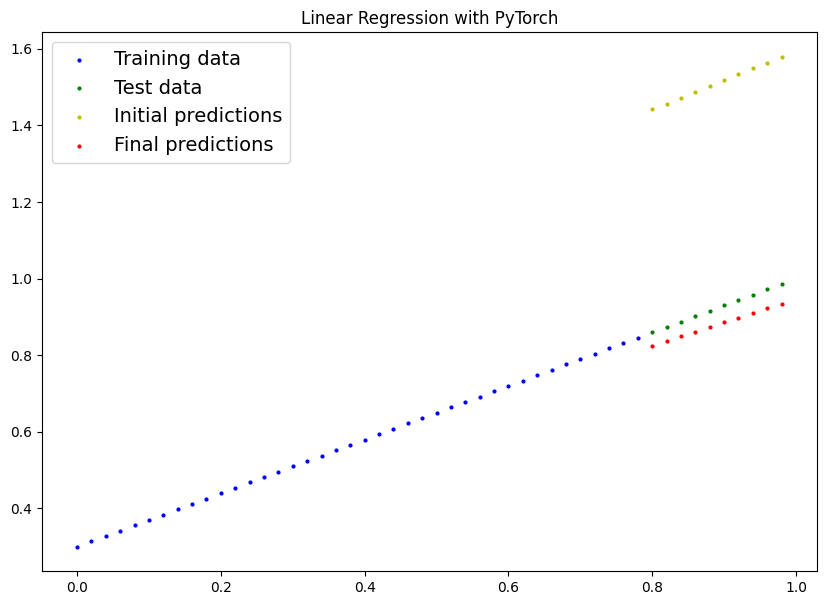

In [ ]:
 # --- 5. Training Loop ---
epochs = 200  # An epoch is one loop through the data ... (this is a hyperparameter beacause we've set it ourselves)


# Create empty lists for storing useful values (helpful for tracking model progress) {track different values}
epoch_count = []
train_loss_values = []
test_loss_values = []



# 0. Loop through the data
for epoch in range(epochs):

    # Set the model to training mode
    model.train() # Train mode in PyTorch sets all paramteters to have "True" value for "gradient requirement"


    # 1. Forward pass (pass the data through the model)
    y_pred = model(X_train)

    # 2. calculate the loss (how wrong the model's predictions are)
    loss = loss_fn(y_pred, y_train)

    # Backpropagation
    # 3. Zero the gradients of the optimizer (they accumulate every epoch, zero them to start fresh each forward pass)
    # optimizer.zero_grad()
    # 4. Perform backpropagation on the loss WRT the parameters of the model (compute the gradient of every parameter with request_grad=True)
    # loss.backward()
    # 5. Step the optimizer (perform gradient descent)
    # optimizer.step()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # --- Testing (every 20 epochs) ---
    model.eval()
    with torch.inference_mode():  # inference_mode will turn off the gradient tracking & a couple of more things behind the scenes
    # The reason is that the gradient descent and backpropatation is only needed for training and when we want to do the testing, we are just
    # evaluating the patterns that our model learned during the training process
        test_pred = model(X_test)  # --> do the forward pass
        test_loss = loss_fn(test_pred, y_test)  # --> calculate the loss



    if epoch % 20 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")
        print(model.state_dict())

# --- 6. Final Results ---
print(f"\nLearned: weight={model.linear_layer.weight.item():.4f}, bias={model.linear_layer.bias.item():.4f}")
print(f"Actual:  weight={weight}, bias={bias}")

# --- 7. Plot Predictions ---
model.eval()
with torch.inference_mode():
    final_preds = model(X_test)

plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Test data")
plt.scatter(X_test, initial_preds, c="y", s=4, label="Initial predictions")
plt.scatter(X_test, final_preds, c="r", s=4, label="Final predictions")
plt.legend(prop={"size": 14})
plt.title("Linear Regression with PyTorch")
plt.show()

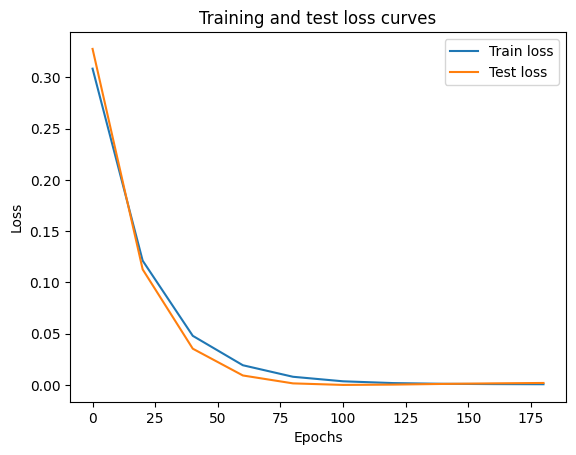

In [ ]:
from prompt_toolkit.shortcuts.progress_bar.formatters import Label
import numpy as np
plt.plot(epoch_count, np.array(torch.tensor(train_loss_values).numpy()), label= "Train loss")
plt.plot(epoch_count, test_loss_values, label= "Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

### Saving a model in PyTorch

#### Resouce:
https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

There are three main methods we should know about for saving and loading models in PyTorch.

1. `torch.save()` - allow us to save a PyTorch object in Python's pickle format
2. `torch.load()` - allow us to load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - this allows us to load a model's saved state dictionary

In [ ]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME


# 3. Save the model state dict
print(f"Saving model of:{MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)


Saving model of:models/01_pytorch_workflow_model.pth


In [ ]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2165 Mar 11 15:24 01_pytorch_workflow_model.pth
